In [1]:
#================================================
# 0. Загружаем библиотеки и подключаем прокси
#================================================
import vectorbt as vbt
import pandas as pd
import numpy as np
import datetime
import os
from dotenv import load_dotenv

# Решаем проблему связки европейского сервера с сервисами предоставления данных
load_dotenv()
proxy_login = os.getenv('PROXY_LOGIN')
proxy_password = os.getenv('PROXY_PASSWORD')
proxy_host = os.getenv('PROXY_HOST')
proxy_port = os.getenv('PROXY_PORT')
proxy_url = f"http://{proxy_login}:{proxy_password}@{proxy_host}:{proxy_port}"
os.environ['HTTP'] = proxy_url
os.environ['HTTPS'] = proxy_url

Start                         2023-06-19 00:00:00+00:00
End                           2026-06-03 00:00:00+00:00
Period                               1081 days 00:00:00
Start Value                                     10000.0
End Value                                  14082.328205
Total Return [%]                              40.823282
Benchmark Return [%]                         148.751695
Max Gross Exposure [%]                       126.737049
Total Fees Paid                                     0.0
Max Drawdown [%]                              39.487269
Max Drawdown Duration                 635 days 00:00:00
Total Trades                                         59
Total Closed Trades                                  58
Total Open Trades                                     1
Open Trade PnL                              1425.885937
Win Rate [%]                                  43.103448
Best Trade [%]                                45.647971
Worst Trade [%]                               -1

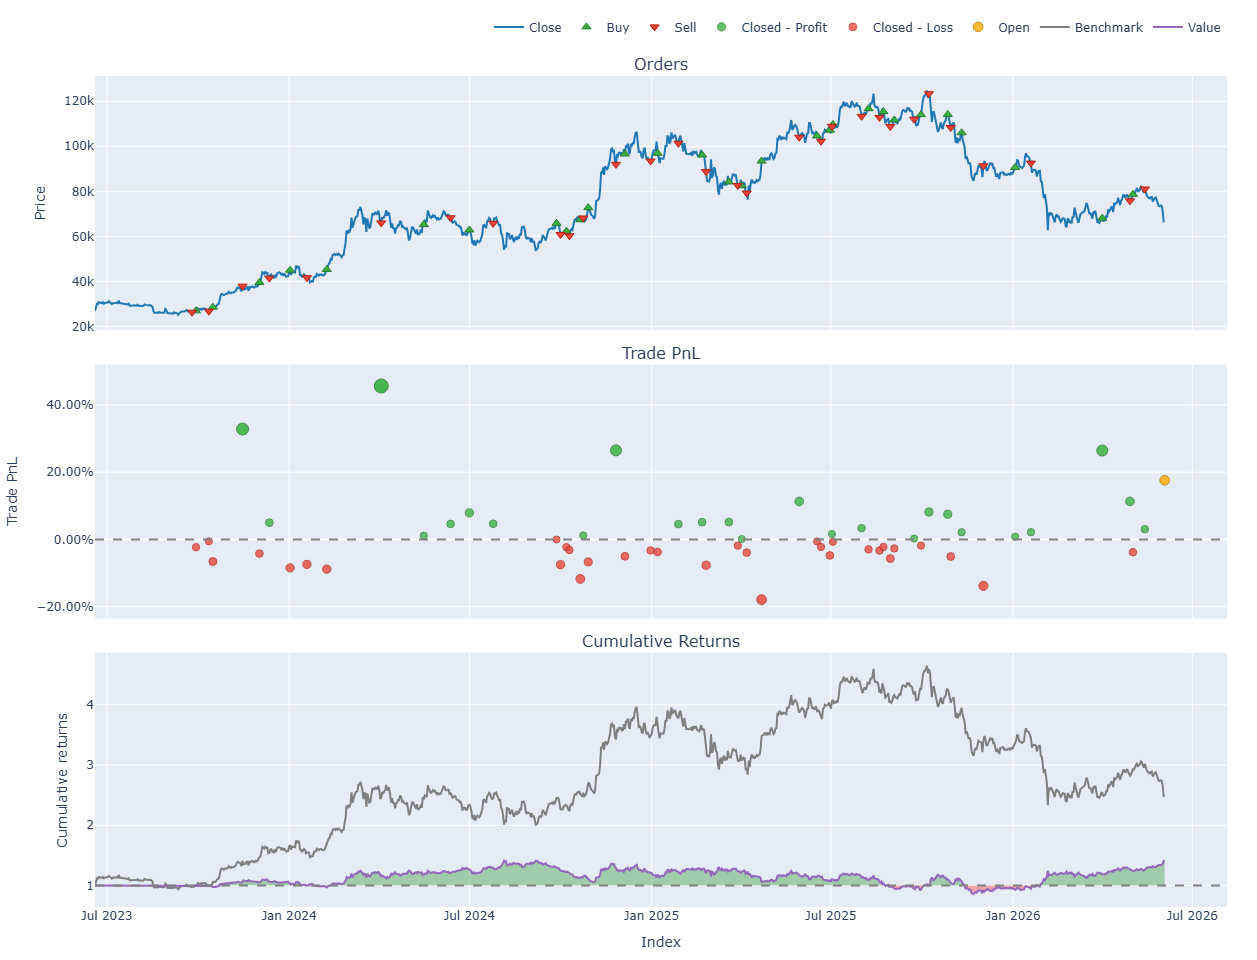

In [2]:
#================================================
# 1. Загружаем и готовим данные
#================================================
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=1080)

btc_price = vbt.YFData.download(
    'BTC-USD',
    missing_index = 'drop',
    start = start_date,
    end = end_date,
    interval = "1d").get()

# Выгрузим данные в OHLC
open_price = btc_price['Open']
high = btc_price['High']
low = btc_price['Low']
close = btc_price['Close']

#=================================================
# 2. Прописываем функцию для индикатора
#=================================================
def breaker_indicator(open_price, high, low, close,
                     lookback = 90,
                     range_days = 5,
                     volatility = 0.02,
                     reward_risk = 5):
    
    # Нам нужны entry_long, entry_short, stop_loss, take_profit, проведем инициализацию
    min_risk = 0.003
    n = len(close)
    entry_long = pd.Series(False, index=close.index)
    entry_short = pd.Series(False, index=close.index)
    take_profit = pd.Series(np.nan, index=close.index)
    stop_loss = pd.Series(np.nan, index=close.index)

    # пройдем по свечам
    for i in range(lookback, n):
        range_start = i - range_days - 1
        range_high = high.iloc[range_start:i-1].max().item()
        range_low = low.iloc[range_start:i-1].min().item()
        range_width = (range_high - range_low)/range_low

        is_narrow_range = range_width <= volatility

        if is_narrow_range:     
            if close.iloc[i-1].item() > range_high:
                entry_long.iloc[i] = True
                stop_loss.iloc[i] = open_price.iloc[i-1]
                risk = open_price.iloc[i].item() - stop_loss.iloc[i].item()
                take_profit.iloc[i] = open_price.iloc[i] + risk*reward_risk
                if risk<min_risk:
                    entry_long.iloc[i] = False
                    stop_loss.iloc[i] = np.nan
                    take_profit.iloc[i] = np.nan
            elif close.iloc[i-1].item() < range_low:
                entry_short.iloc[i] = True
                stop_loss.iloc[i] = open_price.iloc[i-1]
                risk = stop_loss.iloc[i].item() - open_price.iloc[i].item()
                take_profit.iloc[i] = open_price.iloc[i] - risk*reward_risk
                if risk<min_risk:
                    entry_short.iloc[i] = False
                    stop_loss.iloc[i] = np.nan
                    take_profit.iloc[i] = np.nan

    return entry_long, entry_short, take_profit, stop_loss

#================================================
# 3. Оборачиваем индикатор через IndicatorFactory
#================================================
BreakerIndicator = vbt.IndicatorFactory(
    input_names = ['open_price', 'high', 'low', 'close'],
    param_names = ['lookback', 'range_days', 'volatility', 'reward_risk'],
    output_names = ['entry_long', 'entry_short', 'take_profit', 'stop_loss']
).from_apply_func(breaker_indicator,
                  lookback = 90,
                  range_days = 5,
                  volatility = 0.02,
                  reward_risk = 5,
                  keep_pd=True
)

# ============================================================
# 4. ЗАПУСК ИНДИКАТОРА
# ============================================================
res = BreakerIndicator.run(open_price, high, low, close,
                     lookback = 90,
                     range_days = 3,
                     volatility = 0.05,
                     reward_risk = 3)

# ============================================================
# 5. ЗАПУСК БЭКТЕС
# ============================================================
pf = vbt.Portfolio.from_signals(
    close,
    entries = res.entry_long,
    exits=None,
    short_entries = res.entry_short,
    short_exits=None,
    init_cash = 10000,
    size=0.1,
    sl_stop = res.stop_loss,
    tp_stop = res.take_profit,
)

# ============================================================
# 6. АНАЛИЗ
# ============================================================
print(pf.stats())
pf.plot().show()

In [4]:
# ============================================================
# 7. ПОЭКСПЕРИМЕНТИРУЕМ С ПЕРЕБОРОМ ПАРАМЕТРОВ
# ============================================================
vol_combs = [0.05, 0.08, 0.10, 0.12]
days_combs = [3, 5, 7]
rr_combs = [1, 3, 5, 10]

params = []
for vol in vol_combs:
    for rd in days_combs:
        for rr in rr_combs:
            res = BreakerIndicator.run(open_price, high, low, close,
                                       volatility=vol, range_days=rd, reward_risk=rr)
            pf = vbt.Portfolio.from_signals(close, 
                                            res.entry_long, 
                                            short_entries=res.entry_short, 
                                            init_cash = 10000,
                                            size=0.1,
                                            sl_stop = res.stop_loss,
                                            tp_stop = res.take_profit
                                           )
            params.append((vol, rd, rr, pf.total_return()))
        
# 2. Найти лучшую комбинацию
best = max(params, key=lambda x: x[3])
print(f"Лучшие параметры: volatility={best[0]}, range_days={best[1]}, reward/risk={best[2]}, return={best[3]:.2%}")

Лучшие параметры: volatility=0.05, range_days=3, reward/risk=1, return=40.82%
